In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import geopandas as gpd
import statsmodels.formula.api as smf

In [2]:
dat_2020 = gpd.read_file('reviews_demog_2020.gpkg')
dat_2010 = gpd.read_file('reviews_demog_2010.gpkg')


In [3]:
dat_2020.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'neighborhood', 'gentrified',
       'review_id', 'user_id', 'useful', 'funny', 'cool', 'text', 'date',
       'TRACTCE', 'geographic_area_name', 'tot_pop', 'prop_black',
       'prop_asian', 'prop_hispanic_or_latino', 'prop_white_only',
       'overlap_area', 'prop_white_wavg', 'predom_poc', 'no_predom_race',
       'geometry'],
      dtype='str')

In [4]:
dat_2020['text'] = dat_2020.text.str.lower()
dat_2020 = dat_2020.dropna(subset=['text', 'gentrified']).reset_index(drop=True)

In [5]:
dat_2020['authenticity'] = np.where(dat_2020['text'].str.contains('authent'), 1, 0)
dat_2020['beer'] = np.where(dat_2020['text'].str.contains('beer'), 1, 0)
dat_2020['gentrified'] = dat_2020['gentrified'].astype(int)



In [6]:
authenticity_model = smf.logit('gentrified ~ authenticity', data=dat_2020).fit()
print(authenticity_model.summary())

Optimization terminated successfully.
         Current function value: 0.311943
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             gentrified   No. Observations:               681789
Model:                          Logit   Df Residuals:                   681787
Method:                           MLE   Df Model:                            1
Date:                Fri, 08 May 2026   Pseudo R-squ.:               0.0001632
Time:                        22:16:32   Log-Likelihood:            -2.1268e+05
converged:                       True   LL-Null:                   -2.1271e+05
Covariance Type:            nonrobust   LLR p-value:                 7.873e-17
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -2.2586      0.004   -538.357      0.000      -2.267      -2.250
authenticity    -0.2254

In [7]:

marginal_effects_auth = authenticity_model.get_margeff(at='mean')
print(marginal_effects_auth.summary())

        Logit Marginal Effects       
Dep. Variable:             gentrified
Method:                          dydx
At:                              mean
                  dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
authenticity    -0.0192      0.002     -8.087      0.000      -0.024      -0.015


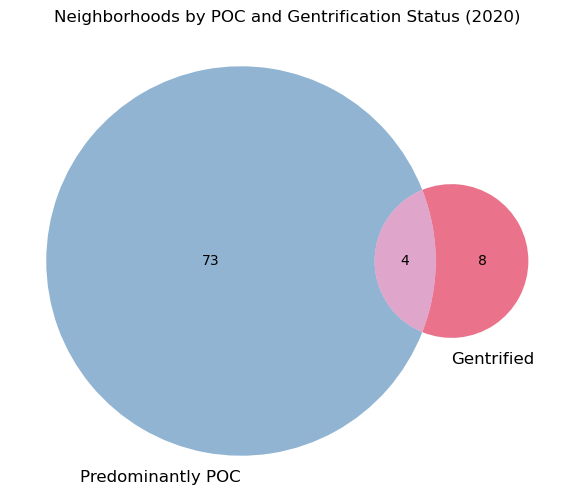

In [8]:


# Get unique neighborhoods in each category
poc_hoods = set(dat_2020[dat_2020['predom_poc'] == 1]['neighborhood'].unique())
gent_hoods = set(dat_2020[dat_2020['gentrified'] == 1]['neighborhood'].unique())

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
venn2([poc_hoods, gent_hoods], 
      set_labels=('Predominantly POC', 'Gentrified'),
      set_colors=('steelblue', 'crimson'),
      alpha=0.6)
plt.title('Neighborhoods by POC and Gentrification Status (2020)')
plt.show()

In [10]:
authenticity_predom_poc = smf.logit('predom_poc ~ authenticity', data=dat_2020).fit()
print(authenticity_predom_poc.summary())

Optimization terminated successfully.
         Current function value: 0.383017
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             predom_poc   No. Observations:               681789
Model:                          Logit   Df Residuals:                   681787
Method:                           MLE   Df Model:                            1
Date:                Fri, 08 May 2026   Pseudo R-squ.:               0.0008586
Time:                        22:29:21   Log-Likelihood:            -2.6114e+05
converged:                       True   LL-Null:                   -2.6136e+05
Covariance Type:            nonrobust   LLR p-value:                 1.306e-99
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.9287      0.004   -522.832      0.000      -1.936      -1.921
authenticity     0.4287

In [13]:
marginal_effects_predom_poc = authenticity_predom_poc.get_margeff(at='mean')
print(marginal_effects_predom_poc.summary())

        Logit Marginal Effects       
Dep. Variable:             predom_poc
Method:                          dydx
At:                              mean
                  dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
authenticity     0.0479      0.002     22.146      0.000       0.044       0.052


In [12]:
authenticity_mixed_model = smf.logit('gentrified ~ authenticity + predom_poc + authenticity:predom_poc', data=dat_2020).fit()
print(authenticity_mixed_model.summary())

Optimization terminated successfully.
         Current function value: 0.309933
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             gentrified   No. Observations:               681789
Model:                          Logit   Df Residuals:                   681785
Method:                           MLE   Df Model:                            3
Date:                Fri, 08 May 2026   Pseudo R-squ.:                0.006607
Time:                        22:29:40   Log-Likelihood:            -2.1131e+05
converged:                       True   LL-Null:                   -2.1271e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -2.1834      0.004   -501.222      0.000      -2.192   

In [14]:
authenticity_mixed_model_marg_effs = authenticity_mixed_model.get_margeff(at='mean')
print(authenticity_mixed_model_marg_effs.summary())

        Logit Marginal Effects       
Dep. Variable:             gentrified
Method:                          dydx
At:                              mean
                             dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
authenticity               -0.0240      0.003     -9.364      0.000      -0.029      -0.019
predom_poc                 -0.0655      0.001    -48.412      0.000      -0.068      -0.063
authenticity:predom_poc     0.0589      0.006      9.432      0.000       0.047       0.071
